### Exploratory Data Analysis

#### Importing Libraries and Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
project_root = Path(".").resolve().parent
df = pd.read_parquet(project_root / "data" / "processed" / "london_housing_2008_24.parquet")

In [8]:
# Adding Borough Column
raw_dir = project_root / "data" / "raw"
borough_map = {}
for fp in sorted(raw_dir.glob("*_link_*.csv")):
    name = fp.name.split("_link")[0].replace("_", " ")
    lad = pd.read_csv(fp, usecols=["lad23cd"], nrows=1)["lad23cd"].iloc[0]
    borough_map[lad] = name

df["borough"] = df["lad23cd"].map(borough_map)

In [13]:
# Adding Log Floor Area Column
df["log_tfarea"] = np.log10(df["tfarea"])

#### EDA

In [14]:
df

,priceper,year,dateoftransfer,propertytype,duration,price,postcode,lad23cd,transactionid,lmk_key,tfarea,numberrooms,classt,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,CONSTRUCTION_AGE_BAND,month,log_price,borough,log_tfarea
0,1115.384615,1999,1999-10-04,F,L,58000,IG11 0XN,E09000002,{C30CDD8C-3FA0-4259-ABE4-CA992C1AC593},126980681552014061013414193040742,52.0,3.0,12,78,81,England and Wales: 1991-1995,10,4.763428,Barking and Dagenham,1.716003
1,2942.307692,2014,2014-09-26,F,L,153000,IG11 0XN,E09000002,{10382CFD-B786-4103-A1C0-B787ED5944FB},126980681552014061013414193040742,52.0,3.0,12,78,81,England and Wales: 1991-1995,9,5.184691,Barking and Dagenham,1.716003
2,2644.230769,2004,2004-10-29,F,L,137500,IG11 0XN,E09000002,{8276E0B3-FDE3-41F4-8DE5-2E589472C69B},126980681552014061013414193040742,52.0,3.0,12,78,81,England and Wales: 1991-1995,10,5.138303,Barking and Dagenham,1.716003
3,902.884615,1997,1997-01-24,F,L,46950,IG11 0XN,E09000002,{2A289E9D-9E69-CDC8-E050-A8C063054829},126980681552014061013414193040742,52.0,3.0,12,78,81,England and Wales: 1991-1995,1,4.671636,Barking and Dagenham,1.716003
4,4206.349206,2023,2023-11-28,F,L,265000,IG11 7GW,E09000002,{152AB733-B73B-E651-E063-4704A8C061D9},5a6e6b6a24c2a840e15b66b8abcb70c3d09b4096b2f5e2...,63.0,3.0,12,76,79,England and Wales: 1996-2002,11,5.423246,Barking and Dagenham,1.799341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2801038,7920.000000,2014,2014-01-08,T,F,594000,W10 4AS,E09000033,{535389DD-E9D8-4BC1-92E1-FD6D7F14E472},9.4983E+32,75.0,4.0,11,60,80,England and Wales: 1900-1929,1,5.773786,Westminster,1.875061
2801039,12900.013330,2024,2024-07-12,T,F,967501,W10 4AS,E09000033,{2131FCF6-462C-86E8-E063-4804A8C0372B},9.4983E+32,75.0,4.0,11,60,80,England and Wales: 1900-1929,7,5.985651,Westminster,1.875061
2801040,4055.944056,2003,2003-01-30,F,L,174000,W9 3PG,E09000033,{9E9DAC1F-D8D9-4DD2-9F35-EE3E90377051},4.10972E+32,42.9,2.0,11,80,84,England and Wales: 1930-1949,1,5.240549,Westminster,1.632457
2801041,2995.337995,2001,2001-07-20,F,L,128500,W9 3PG,E09000033,{626B9E83-4BD3-420D-BCC0-627A049625E7},4.10972E+32,42.9,2.0,11,80,84,England and Wales: 1930-1949,7,5.108903,Westminster,1.632457


In [20]:
corr_map = df.corr(numeric_only=True)
corr_map

,priceper,year,price,tfarea,numberrooms,classt,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,month,log_price,log_tfarea
priceper,1.000000,0.626467,0.715754,0.052746,-0.009307,-0.000206,0.127497,0.061768,0.001569,0.752692,0.002980
year,0.626467,1.000000,0.402861,0.052936,0.075576,-0.051449,0.112802,0.160149,-0.029793,0.702134,0.066346
price,0.715754,0.402861,1.000000,0.538277,0.380720,-0.041812,-0.018153,0.002430,-0.001710,0.720980,0.452486
tfarea,0.052746,0.052936,0.538277,1.000000,0.801665,-0.115459,-0.196335,-0.057131,-0.004612,0.489103,0.935167
numberrooms,-0.009307,0.075576,0.380720,0.801665,1.000000,-0.155037,-0.271079,-0.046566,-0.002783,0.401134,0.824199
classt,-0.000206,-0.051449,-0.041812,-0.115459,-0.155037,1.000000,-0.020165,-0.132483,-0.000818,-0.061203,-0.137685
CURRENT_ENERGY_EFFICIENCY,0.127497,0.112802,-0.018153,-0.196335,-0.271079,-0.020165,1.000000,0.588573,0.005024,0.008960,-0.214644
POTENTIAL_ENERGY_EFFICIENCY,0.061768,0.160149,0.002430,-0.057131,-0.046566,-0.132483,0.588573,1.000000,0.002659,0.044531,-0.032789
month,0.001569,-0.029793,-0.001710,-0.004612,-0.002783,-0.000818,0.005024,0.002659,1.000000,0.006215,-0.003228
log_price,0.752692,0.702134,0.720980,0.489103,0.401134,-0.061203,0.008960,0.044531,0.006215,1.000000,0.489326


<Axes: >

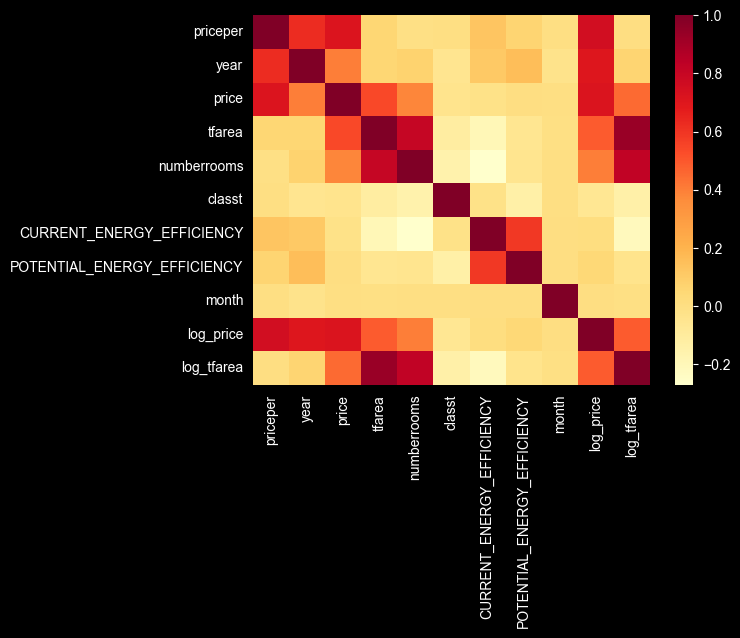

In [21]:
sns.heatmap(corr_map, annot=False, cmap="YlOrRd")